LLM WORKFLOW START->LLM->RESULT->END

In [57]:
from dotenv import load_dotenv
load_dotenv()

True

In [58]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [59]:
from langchain_google_genai import ChatGoogleGenerativeAI


In [60]:
llm=ChatGoogleGenerativeAI(model="gemini-3.6-flash")


In [61]:
#create state first
class LLMState(TypedDict):
    question:str
    answer:str
    

In [62]:
#Create 1st node 
def llmcall(state:LLMState)->LLMState:
    question=state["question"]
    #prompt formation
    prompt=f"Answer The Following Question{question}"
    answer=llm.invoke(question).content
    state["answer"]=answer
    return state

In [63]:
# create graph
graph=StateGraph(LLMState)

In [64]:
#add node
graph.add_node("llmcall",llmcall)

In [65]:
#add edge
graph.add_edge(START,"llmcall")
graph.add_edge("llmcall",END)


In [66]:
#compile 
llmworkflow=graph.compile()

In [54]:
result=llmworkflow.invoke({"question":"What is Ai Agents"})

In [67]:
result

{'question': 'What is Ai Agents',
 'answer': [{'type': 'text',
   'text': 'An **AI Agent** (Artificial Intelligence Agent) is an autonomous software program that can perceive its environment, make decisions, and take actions to achieve a specific goal with little to no human intervention.\n\nWhile traditional AI (like a basic chatbot) simply answers questions when prompted, an **AI Agent is proactive**: you give it a goal, and it breaks that goal down into steps, uses tools, solves problems, and completes the task for you.\n\n---\n\n### The Big Difference: Chatbot vs. AI Agent\n\nTo understand AI agents, it helps to contrast them with standard AI chatbots:\n\n*   **Standard AI (e.g., basic ChatGPT):** \n    *   *You ask:* "What are the best flights to Paris next week?"\n    *   *AI responds:* Gives you a list of airlines and general advice. *You* still have to search, compare, and book.\n*   **AI Agent:**\n    *   *You tell it:* "Book me the cheapest flight to Paris for next Tuesday un

In [69]:
# 1. Access the list inside "answer"
# 2. Grab the first item [0] (the dictionary)
# 3. Access the 'text' key
text_only = result["answer"][0]["text"]

print(text_only)

An **AI Agent** (Artificial Intelligence Agent) is an autonomous software program that can perceive its environment, make decisions, and take actions to achieve a specific goal with little to no human intervention.

While traditional AI (like a basic chatbot) simply answers questions when prompted, an **AI Agent is proactive**: you give it a goal, and it breaks that goal down into steps, uses tools, solves problems, and completes the task for you.

---

### The Big Difference: Chatbot vs. AI Agent

To understand AI agents, it helps to contrast them with standard AI chatbots:

*   **Standard AI (e.g., basic ChatGPT):** 
    *   *You ask:* "What are the best flights to Paris next week?"
    *   *AI responds:* Gives you a list of airlines and general advice. *You* still have to search, compare, and book.
*   **AI Agent:**
    *   *You tell it:* "Book me the cheapest flight to Paris for next Tuesday under $800, and send the itinerary to my calendar."
    *   *Agent responds:* It browses fl

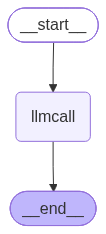

In [70]:
#visualize the workflow

from IPython.display import Image, display
# 4. Draw and display the graph
display(Image(llmworkflow.get_graph().draw_mermaid_png()))
